# Template: learning a 3D energy functional from molecular data

Full pipeline for the `ewaldnn3d` models. **Replace the synthetic-data cell in Step 1
with your own molecules** and the rest runs as is.

**Pipeline**: 1) features, split, normalization → 2) model choice
(LERN / DM21 / EwaldNN / EwaldNN extended) → 3) training, evaluation, introspection.

### Conventions (read once)
- Grid `(N_x, N_y, N_z)`, each a **power of two** (FFT), grid spacing = 1
  (**lattice units**: lengths in grid spacings, momenta like `qs` in inverse grid spacings).
- **Open boundary conditions** via zero padding: your densities must be localized,
  i.e. approximately zero near the box faces.
- Energy convention: `E_tot = (1 / N_x N_y N_z) * sum_r e(r)`.
- **Targets are exchange-correlation energies**: feed `E_xc`, never `V_H + E_xc`. The
  Hartree energy is orders of magnitude larger than `E_xc`, so its subtraction is done at
  the **kernel level**: the EwaldNN mediator kernels are *delta* kernels, screened minus
  bare Coulomb - real space `(exp(-qs r) - 1)/r` (`mediator_repr="rs"`, default; the bare
  part is exactly `1/r`, Hartree convention, see `test_coulomb3d.py`), momentum space
  `-4 pi qs^2 / (q^2 (q^2 + qs^2))` (`"ms"`). The mediator energy is then a Hartree-subtracted
  quantity by construction, never a difference of two separately computed large energies.
  Setting `flag_subtract_H=False` on the EwaldNN models switches the energy term to the
  **unsubtracted** screened field `phi` instead of `dphi`.
- **Feature packing** (all models): the input tensor concatenates
  `[normalized features (N_feat) | raw energy terms E_a(r) (N_energy_terms)]` along the last axis.
  **Feature 0 must be the density** - the models un-normalize it internally to build mediator fields.


In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import math, os

from ewaldnn3d import *

torch.manual_seed(1234)  # reproducibility

# Global settings
dtype = torch.float64    # float32 recommended for N = 128 grids (memory), with a GPU
device = "cuda" if torch.cuda.is_available() else "cpu"
torch.set_default_dtype(dtype)
print(f"device = {device}")


device = cpu


## Step 1a) Data - REPLACE the next cell with your molecules

You need three tensors:

| tensor | shape | content |
|---|---|---|
| `rho` | `(N_data, N_x, N_y, N_z)` | density on the grid |
| `E_terms` | `(N_data, N_x, N_y, N_z, N_energy_terms)` | **raw** (unnormalized) local energy densities, e.g. kinetic, exchange, ... Each channel's spatial mean is that term's baseline energy contribution. |
| `E_target` | `(N_data,)` | **exchange-correlation** energies to fit (Hartree NOT included - the mediator's delta kernel handles the Hartree subtraction internally) |

The synthetic stand-in below mimics molecules (sums of Gaussians) with a ground-truth
functional = locally reweighted kinetic term **plus a screened-minus-bare interaction that
is deliberately NOT provided as an energy term** - so a purely local model must plateau,
and EwaldNN can discover the missing interaction (and we can check the recovered
`qs`, `a` against the truth).


In [2]:
# =====================================================================
# SYNTHETIC DATA - REPLACE THIS CELL WITH YOUR MOLECULES
# =====================================================================
N_x = N_y = N_z = 32
N_data = 64

# molecule-like densities, localized away from the box faces (open BCs)
rho, d_rho_x, d_rho_y, d_rho_z = sample_density_gaussians_batch(
    N_data, N_x, N_y, N_z, n_gauss=3)

# one energy term: kinetic energy density e_kin(r) = 0.5 |grad rho|^2
E_terms = (0.5 * (d_rho_x**2 + d_rho_y**2 + d_rho_z**2)).unsqueeze(-1)  # (N_data, ..., 1)

# ground-truth E_xc-style functional (unknown to the models):
#   E = (1/V) sum_r (1 + 0.3 tanh rho) e_kin(r)         local reweighting
#     + (a_true/2V) sum_r rho (dK[qs_true] * rho)       screened-minus-bare interaction
# with the delta kernel dK(r) = (exp(-qs_true r) - 1)/r - the same kernel-level
# Hartree subtraction the EwaldNN mediator uses
a_true, qs_true = 0.5, 1.0
r_vals = displacement_grid(N_x, N_y, N_z)
dK_true = torch.expm1(-qs_true * r_vals) / r_vals.clamp(min=1.0) * (r_vals > 0)
dphi_true = conv_fft(rho, kernel_eigenvals_fft(dK_true))
E_target = ((1.0 + 0.3 * torch.tanh(rho)) * E_terms[..., 0]).mean(dim=(1, 2, 3)) \
         + 0.5 * a_true * (rho * dphi_true).mean(dim=(1, 2, 3))
print(rho.shape, E_terms.shape, E_target.shape)


torch.Size([64, 32, 32, 32]) torch.Size([64, 32, 32, 32, 1]) torch.Size([64])


## Step 1b) Features, split, normalization

- Build local features from the density (and anything else you have). **Feature 0 = density.**
- For **DM21**: additionally append *static nonlocal* descriptors (fixed-kernel convolutions
  of the density) - set `ADD_STATIC_NONLOCAL = True`. The architecture stays `LERN3d`;
  DM21 is a feature-set choice, not a new model class.
- Split **before** computing normalization statistics; stats come from the train split only.


In [3]:
# ---- local features: powers of the density (feature 0 MUST be the density) ----
features = generate_loc_features_rs(rho, N_pow=2)          # (N_data, ..., 2): rho, rho^2
# append your own local descriptors as extra channels, e.g. the gradient invariant:
# features = torch.cat([features, (d_rho_x**2 + d_rho_y**2 + d_rho_z**2).unsqueeze(-1)], dim=-1)

# ---- DM21-style static nonlocal features (used by the "DM21" model choice) ----
ADD_STATIC_NONLOCAL = False
if ADD_STATIC_NONLOCAL:
    for qs_feat in [0.5, 2.0]:    # FIXED screening widths (not learned)
        K_f = torch.exp(-qs_feat * r_vals) / r_vals.clamp(min=1.0) * (r_vals > 0)
        lam_f = kernel_eigenvals_fft(K_f)
        phi_bar = conv_fft(rho, lam_f) / lam_f.abs().max()   # kernel-weighted density average
        features = torch.cat([features, phi_bar.unsqueeze(-1)], dim=-1)

# ---- train / validation split (BEFORE normalization stats) ----
N_train = int(0.8 * N_data)
perm = torch.randperm(N_data)
idx_tr, idx_va = perm[:N_train], perm[N_train:]

mean_feat, std_feat = compute_normalization_stats(features[idx_tr])   # train stats only
features_norm = normalize_features(features, mean_feat, std_feat)

E_mean = E_target[idx_tr].mean()
E_std  = E_target[idx_tr].std()
y_norm = (E_target - E_mean) / E_std

# ---- pack: [normalized features | raw energy terms] ----
features_packed = torch.cat([features_norm, E_terms], dim=-1)
N_feat = features_norm.shape[-1]
N_energy_terms = E_terms.shape[-1]
print(f"N_feat = {N_feat}, N_energy_terms = {N_energy_terms}")


N_feat = 2, N_energy_terms = 1


## Step 2) Choose a model

| model | what it learns | when to use |
|---|---|---|
| **LERN** | local reweighting factors `f_a(x_r) in [0, 2]` multiplying your energy terms | always start here - it is the baseline that tells you how far local physics goes |
| **DM21** | same as LERN; the features additionally contain *static nonlocal* descriptors | LERN plateaus and you have good fixed descriptors (set `ADD_STATIC_NONLOCAL = True`) |
| **EwaldNN** | + a delta mediator field `dphi = (dK_qs * rho)` with **learnable** `qs` and the delta kernel `dK = K_screened - K_Coulomb`; enters the energy as `(1/2) a(x_r) dphi rho` with a sign-free local reweighting `a(x_r)` (raw linear head), and (screened, normalized) as an extra feature | the missing physics is a pairwise screened interaction of unknown strength / range; inspect the learned `qs`, `a(x_r)` afterwards |
| **EwaldNN extended** | a *menu* `qs_list` of fixed screenings; per-point softmax `s_m(x_r)` selects among the delta fields `dphi_{q_m}`, with the same sign-free local reweighting `a(x_r)` | a single global `qs` underfits - you expect the screening length to vary in space |

Hints:
- `qs` is in **inverse grid spacings**, so the lattice supports `qs in [0, pi]`. The standard
  menu `qs_list = [0, pi/4, pi/2, 3pi/4, pi]` spans no screening (`qs = 0`: the delta kernel
  vanishes identically, so selecting this channel switches the mediator off locally) up to
  screening at the lattice scale (`qs = pi`). Use 3-6 points; their spacing sets how finely
  the extended model can resolve a spatially varying screening.
- **Initialization**: both EwaldNN models start close to a pure local functional - the
  amplitude initializes small (`a = 0.1`, zeroed a-head weights; the linear a-head is
  sign-free, so the data can drive `a` negative) and grows in during training, while `qs`
  initializes at 1 (order-unity lattice screening), where its gradients are healthy. Do NOT
  initialize `qs ~ 0`: there the `a * qs` directions are degenerate and the optimizer gets trapped.
- `flag_subtract_H=True` (default) is the kernel-level Hartree subtraction above. Set it to
  `False` to use the **unsubtracted** screened field `phi` in the energy term instead of
  `dphi`. The features are unchanged either way.
- The extended model costs `2M = 2 len(qs_list)` convolutions per forward pass (screened
  fields for the features, delta fields for the energy; `M` if `flag_subtract_H=False`;
  fine up to `M ~ 10`).
- The amplitude lives entirely in `a(x_r)` - the delta kernels carry none; since the softmax
  weights sum to 1, the extended model subtracts the bare Coulomb exactly once.
- `mediator_repr="rs"` (default) is the bare-Coulomb/Hartree convention; use `"ms"` only if you
  specifically want the momentum-space kernel with uniform mode and self-interaction removed.
- On this synthetic data: LERN/DM21 should plateau (the interaction is withheld from `E_terms`),
  EwaldNN should close the gap and recover `qs_true = 1.0` and `a(x_r) ~ a_true = 0.5`. Expect
  `qs` to converge first; `a` converges more slowly because the trunk can partially mimic the
  interaction through the screened feature (they share explanatory power) - the explicit
  `(1/2) a dphi rho` energy term wins with longer training.


In [ ]:
MODEL_CHOICE = "EwaldNN"   # "LERN" | "DM21" | "EwaldNN" | "EwaldNNExtended"

common = dict(N_x=N_x, N_y=N_y, N_z=N_z, N_energy_terms=N_energy_terms, N_feat=N_feat,
              n_hidden=3, n_neurons=16,
              mean_feat=mean_feat, std_feat=std_feat, E_mean=E_mean, E_std=E_std)

# standard screening menu for the extended model: 5 points spanning [0, pi]
# (lattice units; qs = 0 -> no screening, the delta kernel vanishes there)
qs_list = [0.0, np.pi / 4, np.pi / 2, 3 * np.pi / 4, np.pi]

# kernel-level Hartree subtraction (delta kernels); set False to use the
# unsubtracted screened phi in the energy term
flag_subtract_H = True

if MODEL_CHOICE == "LERN":
    model, learning_regime = LERN3d(**common), "LERN3d"
elif MODEL_CHOICE == "DM21":
    assert ADD_STATIC_NONLOCAL, "DM21 = LERN3d + static nonlocal features: set ADD_STATIC_NONLOCAL = True and re-run Step 1b"
    model, learning_regime = LERN3d(**common), "LERN3d"
elif MODEL_CHOICE == "EwaldNN":
    model, learning_regime = EwaldNN3d(**common, mediator_repr="rs",
                                       flag_subtract_H=flag_subtract_H), "EwaldNN3d"
elif MODEL_CHOICE == "EwaldNNExtended":
    model, learning_regime = EwaldNNExtended3d(**common, qs_list=qs_list, mediator_repr="rs",
                                               flag_subtract_H=flag_subtract_H), "EwaldNNExtended3d"
else:
    raise ValueError(MODEL_CHOICE)

model = model.to(device)
print(f"{MODEL_CHOICE}: {sum(p.numel() for p in model.parameters())} parameters")


## Step 3) Training

`train_with_early_stopping` checkpoints the best-validation model to
`ckpt_dir/{run_name}_best.pt` (with the config and normalization stats needed to rebuild it)
and writes the loss history to a CSV. Adjust `max_epochs` / `patience` for production runs;
for `N = 128` grids move to GPU, `float32`, and reduce the batch size to fit memory.


In [ ]:
train_loader = DataLoader(TensorDataset(features_packed[idx_tr], y_norm[idx_tr]),
                          batch_size=16, shuffle=True)
val_loader   = DataLoader(TensorDataset(features_packed[idx_va], y_norm[idx_va]), batch_size=16)

criterion = torch.nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=10)

ckpt_dir = "Learning3d_checkpoints"
# "_noH" marks flag_subtract_H = False runs so they don't overwrite the default ones
run_name = f"template_{MODEL_CHOICE}_{N_x}_{N_feat}_{N_energy_terms}" \
         + ("" if flag_subtract_H else "_noH")

hist, best_epoch = train_with_early_stopping(
    model, train_loader, val_loader, criterion, optimizer, scheduler=scheduler,
    max_epochs=400,        # a few minutes at N = 32 on CPU; increase for production
    patience=40,
    ckpt_dir=ckpt_dir, run_name=run_name, learning_regime=learning_regime,
    N_x=N_x, N_y=N_y, N_z=N_z, device=device)


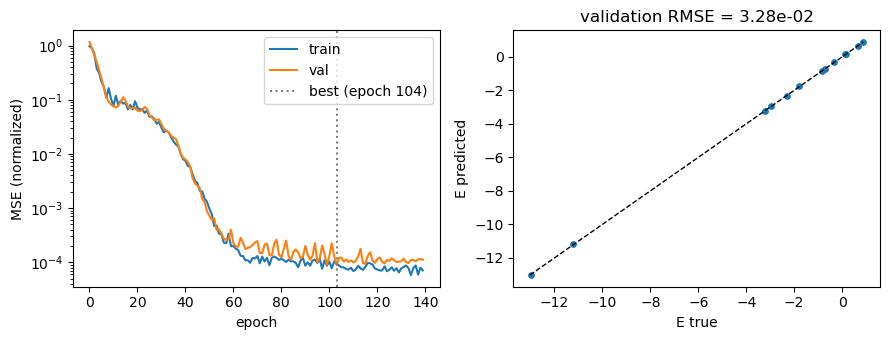

In [6]:
# ---- learning curves and validation parity ----
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))
axes[0].semilogy(hist["train_loss"], label="train")
axes[0].semilogy(hist["val_loss"], label="val")
axes[0].axvline(best_epoch - 1, color="gray", ls=":", label=f"best (epoch {best_epoch})")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("MSE (normalized)"); axes[0].legend()

model.eval()
with torch.no_grad():
    E_pred = torch.cat([model(xb.to(device)).cpu() for xb, _ in val_loader]) * E_std + E_mean
E_true = E_target[idx_va]
rmse = ((E_pred - E_true) ** 2).mean().sqrt()
axes[1].scatter(E_true, E_pred, s=15)
lims = [min(E_true.min(), E_pred.min()), max(E_true.max(), E_pred.max())]
axes[1].plot(lims, lims, "k--", lw=1)
axes[1].set_xlabel("E true"); axes[1].set_ylabel("E predicted")
axes[1].set_title(f"validation RMSE = {rmse:.2e}")
plt.tight_layout(); plt.show()


learned screening momentum qs = 0.997   (synthetic truth: 1.0)


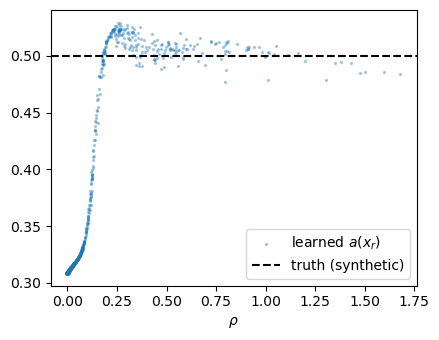

In [7]:
# ---- introspection: what did the model learn? ----
if MODEL_CHOICE in ("LERN", "DM21"):
    # learned reweighting factor f_1 vs density, against the synthetic truth
    with torch.no_grad():
        f = model.local_nn(features_norm[idx_va].to(device))[..., 0].cpu()
    plt.figure(figsize=(4.5, 3.5))
    plt.scatter(rho[idx_va].flatten()[::197], f.flatten()[::197], s=2, alpha=0.3,
                label="learned $f_1(x_r)$")
    rr = torch.linspace(rho.min(), rho.max(), 100)
    plt.plot(rr, 1 + 0.3 * torch.tanh(rr), "k--", label="truth (synthetic)")
    plt.xlabel(r"$\rho$"); plt.legend(); plt.tight_layout(); plt.show()

elif MODEL_CHOICE == "EwaldNN":
    qs_learned = F.softplus(model.mediator.raw_qs).item()
    print(f"learned screening momentum qs = {qs_learned:.3f}   (synthetic truth: {qs_true})")
    # local mediator reweighting a(x_r) (raw linear head, either sign) - on this
    # data the truth is the constant a_true
    with torch.no_grad():
        xb = features_packed[idx_va].to(device)
        rho_va = model._rho_from_features(xb[..., :N_feat])
        _, phi_feat = model.mediator.phi_and_feature(rho_va)
        phi_feat = phi_feat / model.std_feat[..., 0]
        z = model.local_nn(torch.cat([xb[..., :N_feat], phi_feat.unsqueeze(-1)], dim=-1))
        a_fac = z[..., model.N_energy_terms].cpu()
    plt.figure(figsize=(4.5, 3.5))
    plt.scatter(rho[idx_va].flatten()[::197], a_fac.flatten()[::197], s=2, alpha=0.3,
                label="learned $a(x_r)$")
    plt.axhline(a_true, color="k", ls="--", label="truth (synthetic)")
    plt.xlabel(r"$\rho$"); plt.legend(); plt.tight_layout(); plt.show()

elif MODEL_CHOICE == "EwaldNNExtended":
    # softmax occupations: which screening channel does each grid point select?
    with torch.no_grad():
        xb = features_packed[idx_va].to(device)
        rho_va = model._rho_from_features(xb[..., :N_feat])
        phi_stack = torch.stack([conv_fft(rho_va, model.lam_K[m].to(dtype=rho_va.dtype))
                                 for m in range(model.M)], dim=-1)
        phi_feat = (phi_stack / model.lam_norm) / model.std_feat[..., 0]
        z = model.local_nn(torch.cat([xb[..., :N_feat], phi_feat], dim=-1))
        a_fac = z[..., model.N_energy_terms].cpu()
        s = torch.softmax(z[..., model.N_energy_terms + 1:], dim=-1).cpu()
    print(f"mean mediator reweighting a(x_r) = {a_fac.mean():.3f}")
    print("mean softmax occupation per screening channel:")
    for qs_m, o in zip(model.qs_list, s.mean(dim=(0, 1, 2, 3))):
        print(f"   qs = {qs_m}: {o:.3f}")


In [8]:
# ---- reload the best checkpoint (as you would in a fresh session) ----
model_class = {"LERN": LERN3d, "DM21": LERN3d,
               "EwaldNN": EwaldNN3d, "EwaldNNExtended": EwaldNNExtended3d}[MODEL_CHOICE]
model_re, normalization, epoch, val_loss = load_checkpoint(
    os.path.join(ckpt_dir, f"{run_name}_best.pt"), model_class, device=device)
with torch.no_grad():
    xb, _ = next(iter(val_loader))
    err = (model(xb.to(device)) - model_re(xb.to(device))).abs().max().item()
print(f"best epoch {epoch}, val loss {val_loss:.3e}, reload consistency err = {err:.1e}")


best epoch 104, val loss 8.848e-05, reload consistency err = 0.0e+00
